# PBMF vs. Langevin: non-Gaussianity comparison

Compares the PBMF theory against the Langevin simulation data, using the files produced by:
- `preprocess_PBMF_distributions.py` (PBMF side, in `processing_data/PBMF/`)
- `aggregate_equilibrium_pdfs.py` + `preprocess_Langevin_distributions.py` (Langevin side, in `processing_data/Langevin/`)

This notebook is self-contained: it does not import from `plot_PBMF_gaussianity.ipynb` or from either preprocessing script (some small helpers are copied where needed, so the two notebooks/scripts stay independent).

Two sections:
1. **Average distributions** -- PBMF theory vs. Langevin simulation, as a frequency histogram and as a count histogram.
2. **Individual species distributions** -- the same two histograms, for the species PBMF flagged as most non-Gaussian (see `--pbmf-dir` in `preprocess_Langevin_distributions.py`).

Both comparisons work the same way: PBMF's distribution is normally given as a probability density on its own (fine, analytic) grid, while the simulation's distribution is a histogram on a coarser, shared grid (see `aggregate_equilibrium_pdfs.py`'s `--nmin`/`--nmax`/`--dn`). To compare them directly, PBMF's density is *integrated* over the simulation's bins (optionally merged into fewer, user-chosen bins first) to get an equivalent frequency, and that frequency is scaled by `N_SAMPLES` (the number of samples pooled per species in the simulation, a fixed run parameter -- 10000 for the current data) to get an equivalent count.

In [1]:
import os
import re
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "axes.linewidth": 1.2,
})

## Configuration

In [2]:
PBMF_DIR = "/run/media/david/Data/Research/Ecology/Results/PBMF/Several_epsilon"
PBMF_DIST_DIR = os.path.join(PBMF_DIR, "Distributions")

LANGEVIN_DIR = "/run/media/david/Data/Research/Ecology/Langevin/Results/PDF"
LANGEVIN_DIST_DIR = os.path.join(LANGEVIN_DIR, "Distributions")

# Total number of samples pooled per species in the Langevin simulation (N_ext * N_meas in
# Ecosystem_Dynamics_on_Graphs_in_Temperature.cpp's own terms). PBMF has no such notion (it is
# a density, not a sample of anything), so this is what turns PBMF's (density-derived)
# frequency into an equivalent, directly comparable count scale.
N_SAMPLES = 10000

## Shared helpers

Filename parsing is copied from `preprocess_PBMF_distributions.py` / `preprocess_Langevin_distributions.py` rather than imported, so this notebook has no dependency on either script.

In [3]:
# --- PBMF filenames (copied from preprocess_PBMF_distributions.py) ---

PBMF_FILENAME_RE = re.compile(
    r"eps_(?P<eps>[0-9.eE+-]+)_mu_(?P<mu>[0-9.eE+-]+)_sigma_(?P<sigma>[0-9.eE+-]+)"
    r"_N_(?P<N>\d+)_c_(?P<c>\d+)_sgraph_(?P<sgraph>\d+)"
    r"_LV_av0_(?P<av0>[0-9.eE+-]+)_stdn0_(?P<stdn0>[0-9.eE+-]+)"
    r"_T_(?P<T>[0-9.eE+-]+)_lda_(?P<lda>[0-9.eE+-]+)_tol_(?P<tol>[0-9.eE+-]+)"
    r"_maxiter_(?P<maxiter>\d+)_damping_(?P<damping>[0-9.eE+-]+)"
    r"_n1_(?P<n1>[0-9.eE+-]+)_dn_(?P<dn>[0-9.eE+-]+)_nmaxlimit_(?P<nmaxlimit>[0-9.eE+-]+)"
    r"_distributions_seedseq_(?P<seedseq>\d+)_seedinit_(?P<seedinit>\d+)\.txt$"
)
PBMF_AVG_DIST_SUFFIX = "_avg_dist_fit.txt"
PBMF_TOP_NONGAUSSIAN_SUFFIX = "_top_nongaussian_species.txt"
PBMF_AVG_DIST_COLUMNS = {"n": 0, "P_avg": 1, "Phat_avg": 2, "P_median": 3, "Phat_median": 4, "P_std": 5, "Phat_std": 6}


def parse_pbmf_filename(name):
    m = PBMF_FILENAME_RE.search(name)
    if m is None:
        return None
    d = {k: float(v) for k, v in m.groupdict().items()}
    for int_key in ("N", "c", "sgraph", "maxiter", "seedseq", "seedinit"):
        d[int_key] = int(d[int_key])
    return d


# --- Langevin filenames (copied from preprocess_Langevin_distributions.py) ---

LANGEVIN_FILENAME_RE = re.compile(
    r"^Lotka-Volterra_epsilon_(?P<epsilon>[^_]+)_(?P<ia_label>.+)_lambda_(?P<lambda_>[^_]+)"
    r"_h_(?P<h>[^_]+)_tmax_(?P<tmax>[^_]+)_deltatsave_(?P<deltatsave>[^_]+)"
    r"_N_(?P<N>\d+)_c_(?P<c>[^_]+)_mu_(?P<mu>[^_]+)_sigma_(?P<sigma>[^_]+)_T_(?P<T>[^_]+)"
    r"_PDF\.txt$"
)
LANGEVIN_AVG_DIST_SUFFIX = "_avg_dist_fit.txt"
LANGEVIN_PBMF_TOP_NONGAUSSIAN_SUFFIX = "_PBMF_top_nongaussian_species.txt"
LANGEVIN_AVG_DIST_COLUMNS = {
    "n": 0,
    "P_count_avg": 1, "P_count_median": 2, "P_count_std": 3,
    "P_freq_avg": 4, "P_freq_median": 5, "P_freq_std": 6,
    "P_density_avg": 7, "P_density_median": 8, "P_density_std": 9,
    "Phat_freq_avg": 10, "Phat_freq_median": 11, "Phat_freq_std": 12,
    "Phat_density_avg": 13, "Phat_density_median": 14, "Phat_density_std": 15,
}


def parse_langevin_filename(name):
    m = LANGEVIN_FILENAME_RE.match(name)
    if m is None:
        return None
    d = dict(m.groupdict())
    d["lambda"] = d.pop("lambda_")
    for key in ("epsilon", "lambda", "h", "tmax", "deltatsave", "c", "mu", "sigma", "T"):
        d[key] = float(d[key])
    d["N"] = int(d["N"])
    return d


# --- Shared plotting helper ---

def _add_style_legend(ax, loc="lower left", fontsize=11):
    """Add a second, fixed legend clarifying that points are the simulation and lines are
    PBMF theory, independent of the color-coded (eps/sigma/species) legend already on ax.
    Must be called after ax.legend(...) has already been captured into a variable and
    detached via ax.add_artist(...), since a second ax.legend(...) call would otherwise
    silently remove the first one."""
    handles = [
        Line2D([0], [0], color="black", marker="o", linestyle="none", markersize=5, label="Simulation"),
        Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="PBMF (theory)"),
    ]
    style_legend = ax.legend(handles=handles, loc=loc, fontsize=fontsize, frameon=False, handlelength=2.5)
    ax.add_artist(style_legend)

In [4]:
def rebin_columns(native_centers, native_count, native_freq, dn_native, n_bins_user):
    """Merge a simulation's native (fine) per-bin count/frequency into n_bins_user coarser
    bins spanning the same overall range. Density is recomputed from the merged frequency
    (density = freq / new bin width), since density is not itself additive across merged bins.

    n_bins_user must not exceed the number of native bins -- coarser bins can be built by
    merging finer ones, but finer bins cannot be recovered from already-binned data.
    """
    n_bins_native = len(native_centers)
    if n_bins_user > n_bins_native:
        raise ValueError(
            f"n_bins ({n_bins_user}) must not exceed the number of bins already present in "
            f"the simulation data ({n_bins_native})."
        )
    native_edges = np.concatenate([native_centers - dn_native / 2, [native_centers[-1] + dn_native / 2]])
    new_edges = native_edges if n_bins_user == n_bins_native else np.linspace(native_edges[0], native_edges[-1], n_bins_user + 1)
    new_centers = 0.5 * (new_edges[:-1] + new_edges[1:])
    dn_new = new_edges[1] - new_edges[0]

    bin_idx = np.clip(np.digitize(native_centers, new_edges[1:-1]), 0, n_bins_user - 1)
    new_count = np.zeros(n_bins_user)
    new_freq = np.zeros(n_bins_user)
    np.add.at(new_count, bin_idx, native_count)
    np.add.at(new_freq, bin_idx, native_freq)
    new_density = new_freq / dn_new
    return new_edges, new_centers, new_count, new_freq, new_density


def _bin_weights(n, bin_edges):
    """For each of len(bin_edges)-1 bins, return (x_in_bin, weights) such that
    sum(weights * y_at_x_in_bin) == trapz(y, x) restricted to that bin. Falls back to the two
    bin edges (each weighted by half the bin width, and evaluated by linear interpolation)
    when fewer than 2 native grid points fall inside."""
    n_bins = len(bin_edges) - 1
    out = []
    for k in range(n_bins):
        lo, hi = bin_edges[k], bin_edges[k + 1]
        mask = (n >= lo) & (n <= hi)
        if mask.sum() >= 2:
            x_in = n[mask]
            dx = np.diff(x_in)
            w = np.empty_like(x_in)
            w[0] = dx[0] / 2
            w[-1] = dx[-1] / 2
            w[1:-1] = (dx[:-1] + dx[1:]) / 2
        else:
            x_in = np.array([lo, hi])
            w = np.array([(hi - lo) / 2, (hi - lo) / 2])
        out.append((x_in, w))
    return out


def integrate_over_bins(n, y, bin_edges):
    """Integrate y(n) over each of len(bin_edges)-1 bins via the trapezoidal rule -- this is
    how PBMF's density is turned into a frequency (probability mass) on the simulation's bins."""
    out = np.empty(len(bin_edges) - 1)
    for k, (x_in, w) in enumerate(_bin_weights(n, bin_edges)):
        out[k] = np.sum(w * np.interp(x_in, n, y))
    return out

## 1. Average distributions: PBMF theory vs. Langevin simulation

For a given (epsilon, sigma), PBMF's species-averaged distribution is pooled (mean) over every `sgraph`/`seedinit` replicate it was run with; the Langevin side is already a single, pre-pooled `*_avg_dist_fit.txt` file (see `preprocess_Langevin_distributions.py`).

In [5]:
def find_pbmf_avg_dist_files(pbmf_dist_dir, eps, sigma, sgraph=None, tol=1e-6):
    """Every PBMF *_avg_dist_fit.txt file matching (eps, sigma) -- and, if sgraph is given,
    one specific graph realization; otherwise every sgraph/seedinit replicate."""
    pattern = os.path.join(pbmf_dist_dir, f"PBMF_gr_in_RRG_*{PBMF_AVG_DIST_SUFFIX}")
    matches = []
    for path in sorted(glob.glob(pattern)):
        reconstructed = os.path.basename(path)[:-len(PBMF_AVG_DIST_SUFFIX)] + ".txt"
        params = parse_pbmf_filename(reconstructed)
        if params is None:
            continue
        if not (np.isclose(params["eps"], eps, atol=tol) and np.isclose(params["sigma"], sigma, atol=tol)):
            continue
        if sgraph is not None and params["sgraph"] != sgraph:
            continue
        matches.append(path)
    return matches


def load_pbmf_pooled_average(pbmf_dist_dir, eps, sigma, column="P_avg", sgraph=None):
    """Pool (mean) the given column of every PBMF avg_dist_fit.txt file matching (eps, sigma)
    -- and, if sgraph is given, one specific graph realization (pooling then only over its
    seedinit replicates); otherwise every sgraph/seedinit replicate. Replicates share the same
    grid start/step but can have different lengths (the solver only extends the grid as far as
    it needs), so shorter replicates are zero-padded up to the longest grid before averaging.

    Returns (n, pooled_mean, n_replicates); (None, None, 0) if no file is found.
    """
    paths = find_pbmf_avg_dist_files(pbmf_dist_dir, eps, sigma, sgraph=sgraph)
    if not paths:
        return None, None, 0
    col = PBMF_AVG_DIST_COLUMNS[column]
    curves = [np.loadtxt(path, skiprows=1)[:, [0, col]] for path in paths]
    n_ref = max((c[:, 0] for c in curves), key=len)
    stacked = np.zeros((len(curves), len(n_ref)))
    for i, c in enumerate(curves):
        stacked[i, :len(c)] = c[:, 1]
    return n_ref, stacked.mean(axis=0), len(paths)


def find_langevin_avg_dist_file(langevin_dist_dir, eps, sigma, tol=1e-6):
    """The single Langevin *_avg_dist_fit.txt file matching (eps, sigma) (there is only ever
    one -- every extraction/measure is already pooled before this file is written)."""
    pattern = os.path.join(langevin_dist_dir, f"Lotka-Volterra_*{LANGEVIN_AVG_DIST_SUFFIX}")
    for path in sorted(glob.glob(pattern)):
        reconstructed = os.path.basename(path)[:-len(LANGEVIN_AVG_DIST_SUFFIX)] + ".txt"
        params = parse_langevin_filename(reconstructed)
        if params is None:
            continue
        if np.isclose(params["epsilon"], eps, atol=tol) and np.isclose(params["sigma"], sigma, atol=tol):
            return path
    return None


def list_available_eps(langevin_dist_dir, sigma, tol=1e-6):
    """Every epsilon value that has a Langevin avg_dist_fit file for this sigma -- the default
    eps_values used by plot_avg_*_histogram_vs_eps when none are given explicitly."""
    pattern = os.path.join(langevin_dist_dir, f"Lotka-Volterra_*{LANGEVIN_AVG_DIST_SUFFIX}")
    values = set()
    for path in sorted(glob.glob(pattern)):
        reconstructed = os.path.basename(path)[:-len(LANGEVIN_AVG_DIST_SUFFIX)] + ".txt"
        params = parse_langevin_filename(reconstructed)
        if params is not None and np.isclose(params["sigma"], sigma, atol=tol):
            values.add(params["epsilon"])
    return sorted(values)


def list_available_sigma(langevin_dist_dir, eps, tol=1e-6):
    """Every sigma value that has a Langevin avg_dist_fit file for this epsilon -- the default
    sigma_values used by plot_avg_*_histogram_vs_sigma when none are given explicitly."""
    pattern = os.path.join(langevin_dist_dir, f"Lotka-Volterra_*{LANGEVIN_AVG_DIST_SUFFIX}")
    values = set()
    for path in sorted(glob.glob(pattern)):
        reconstructed = os.path.basename(path)[:-len(LANGEVIN_AVG_DIST_SUFFIX)] + ".txt"
        params = parse_langevin_filename(reconstructed)
        if params is not None and np.isclose(params["epsilon"], eps, atol=tol):
            values.add(params["sigma"])
    return sorted(values)

In [6]:
def _plot_avg_multi(n_bins, kind, eps=None, sigma=None, values=None, sgraph=None, use_phat=False,
                     pbmf_dist_dir=PBMF_DIST_DIR, langevin_dist_dir=LANGEVIN_DIST_DIR,
                     n_samples=N_SAMPLES, figsize=(8, 6), dpi=150, legend_loc='best', legend_fontsize=14,
                     title_fontsize=18, label_fontsize=20, tick_fontsize=14, linewidth=2, markersize=4,
                     logscalex=False, logscaley=False, ax=None, save_to=None,
                     xmin=None, xmax=None, ymin=None, ymax=None, title=None):
    """Overlay several (epsilon, sigma) curve-pairs (simulation as small points at bin
    centers + PBMF theory as a solid line, one color per value) in one plot. Exactly one of
    eps/sigma must be given (the fixed one); the other varies over `values` (every value found
    in the Langevin data, if not given).

    sgraph, if given, restricts PBMF's pooling to that one graph realization (otherwise every
    sgraph/seedinit replicate is pooled, as in load_pbmf_pooled_average).
    """
    if kind not in ("frequency", "count"):
        raise ValueError("kind must be 'frequency' or 'count'")
    if (eps is None) == (sigma is None):
        raise ValueError("Specify exactly one of eps (fixed) or sigma (fixed); the other varies over `values`.")
    vary_eps = eps is None

    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "axes.linewidth": 1.2,
    })

    if values is None:
        values = list_available_eps(langevin_dist_dir, sigma) if vary_eps else list_available_sigma(langevin_dist_dir, eps)
    if not values:
        print("  [warn] no matching Langevin avg_dist_fit files found")
        return

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        fig.subplots_adjust(left=0.17, bottom=0.14, right=0.98, top=0.90)
    else:
        fig = ax.figure
    color_cycle = plt.cm.tab20(np.linspace(0, 1, max(len(values), 1)))

    for idx, val in enumerate(values):
        this_eps = val if vary_eps else eps
        this_sigma = sigma if vary_eps else val
        color = color_cycle[idx % len(color_cycle)]

        langevin_path = find_langevin_avg_dist_file(langevin_dist_dir, this_eps, this_sigma)
        if langevin_path is None:
            print(f"  [warn] no Langevin avg_dist_fit file for eps={this_eps}, sigma={this_sigma}")
            continue
        data = np.loadtxt(langevin_path, skiprows=1)
        native_centers = data[:, LANGEVIN_AVG_DIST_COLUMNS["n"]]
        dn_native = native_centers[1] - native_centers[0]
        if use_phat:
            native_freq = data[:, LANGEVIN_AVG_DIST_COLUMNS["Phat_freq_avg"]]
            native_count = native_freq * n_samples
        else:
            native_freq = data[:, LANGEVIN_AVG_DIST_COLUMNS["P_freq_avg"]]
            native_count = data[:, LANGEVIN_AVG_DIST_COLUMNS["P_count_avg"]]

        new_edges, new_centers, sim_count, sim_freq, _sim_density = rebin_columns(
            native_centers, native_count, native_freq, dn_native, n_bins
        )

        pbmf_n, pbmf_density, n_replicates = load_pbmf_pooled_average(
            pbmf_dist_dir, this_eps, this_sigma, column="Phat_avg" if use_phat else "P_avg", sgraph=sgraph
        )
        if pbmf_n is None:
            print(f"  [warn] no PBMF avg_dist_fit files for eps={this_eps}, sigma={this_sigma}")
            continue
        pbmf_freq = integrate_over_bins(pbmf_n, pbmf_density, new_edges)
        pbmf_count = pbmf_freq * n_samples

        sim_vals = sim_freq if kind == "frequency" else sim_count
        pbmf_vals = pbmf_freq if kind == "frequency" else pbmf_count

        label = fr"$\epsilon={val:.2f}$" if vary_eps else fr"$\sigma={val:.2f}$"
        ax.plot(new_centers, sim_vals, marker="o", linestyle="none", markersize=markersize,
                color=color, label=label)
        ax.step(new_edges, np.append(pbmf_vals, pbmf_vals[-1]), where="post",
                linewidth=linewidth, color=color)

    if logscalex:
        ax.set_xscale("log")
    if logscaley:
        ax.set_yscale("log")
    ax.set_xlabel(r"$n$", fontsize=label_fontsize)
    ylabel = "Frequency" if kind == "frequency" else "Count"
    if use_phat:
        ylabel += r" of $\hat{P}(n)$"
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    fixed_label = fr"$\sigma={sigma:.2f}$" if vary_eps else fr"$\epsilon={eps:.2f}$"
    sgraph_label = f", sgraph={sgraph}" if sgraph is not None else ""
    ttl = title if title is not None else f"{fixed_label}{sgraph_label} ({n_bins} bins)"
    ax.set_title(ttl, fontsize=title_fontsize)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=3)
    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=5)
    if logscalex:
        ax.xaxis.set_major_formatter(LogFormatterMathtext())
    if logscaley:
        ax.yaxis.set_major_formatter(LogFormatterMathtext())

    main_legend = ax.legend(loc=legend_loc, fontsize=legend_fontsize, frameon=False, handlelength=2.5)
    ax.add_artist(main_legend)
    _add_style_legend(ax)

    if xmin is not None:
        ax.set_xlim(left=xmin)
    if xmax is not None:
        ax.set_xlim(right=xmax)
    if ymin is not None:
        ax.set_ylim(bottom=ymin)
    if ymax is not None:
        ax.set_ylim(top=ymax)

    if save_to is not None:
        fig.savefig(save_to)
    plt.show()


def plot_avg_frequency_histogram_vs_eps(sigma, n_bins, eps_values=None, **kwargs):
    """Frequency histogram, one curve-pair per epsilon, for a fixed sigma (see _plot_avg_multi;
    pass sgraph=<n> to restrict PBMF to one graph realization instead of pooling all of them)."""
    _plot_avg_multi(n_bins, kind="frequency", sigma=sigma, values=eps_values, **kwargs)


def plot_avg_count_histogram_vs_eps(sigma, n_bins, eps_values=None, **kwargs):
    """Like plot_avg_frequency_histogram_vs_eps, but on a count scale (frequency * n_samples
    for both sides -- see the N_SAMPLES configuration cell)."""
    _plot_avg_multi(n_bins, kind="count", sigma=sigma, values=eps_values, **kwargs)


def plot_avg_frequency_histogram_vs_sigma(eps, n_bins, sigma_values=None, **kwargs):
    """Frequency histogram, one curve-pair per sigma, for a fixed epsilon (see _plot_avg_multi;
    pass sgraph=<n> to restrict PBMF to one graph realization instead of pooling all of them)."""
    _plot_avg_multi(n_bins, kind="frequency", eps=eps, values=sigma_values, **kwargs)


def plot_avg_count_histogram_vs_sigma(eps, n_bins, sigma_values=None, **kwargs):
    """Like plot_avg_frequency_histogram_vs_sigma, but on a count scale (frequency * n_samples
    for both sides -- see the N_SAMPLES configuration cell)."""
    _plot_avg_multi(n_bins, kind="count", eps=eps, values=sigma_values, **kwargs)

In [7]:
eps_list = [1.0, 0.8, 0.6, 0.4, 0.2, 0.0]

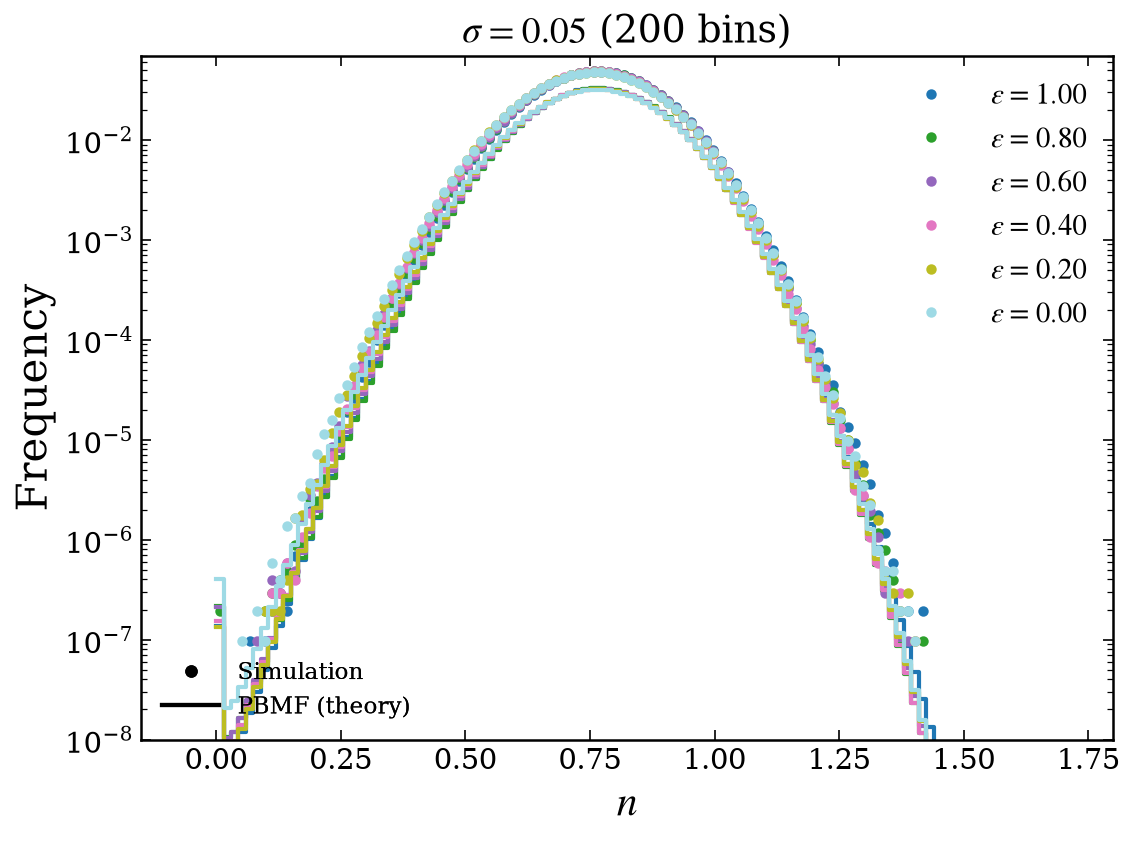

In [28]:
# Fixed sigma, one curve-pair per epsilon
plot_avg_frequency_histogram_vs_eps(sigma=0.05, n_bins=200, eps_values=eps_list, 
                                    ymin=1e-8, ymax=7e-2, xmax=1.8, logscaley=True)

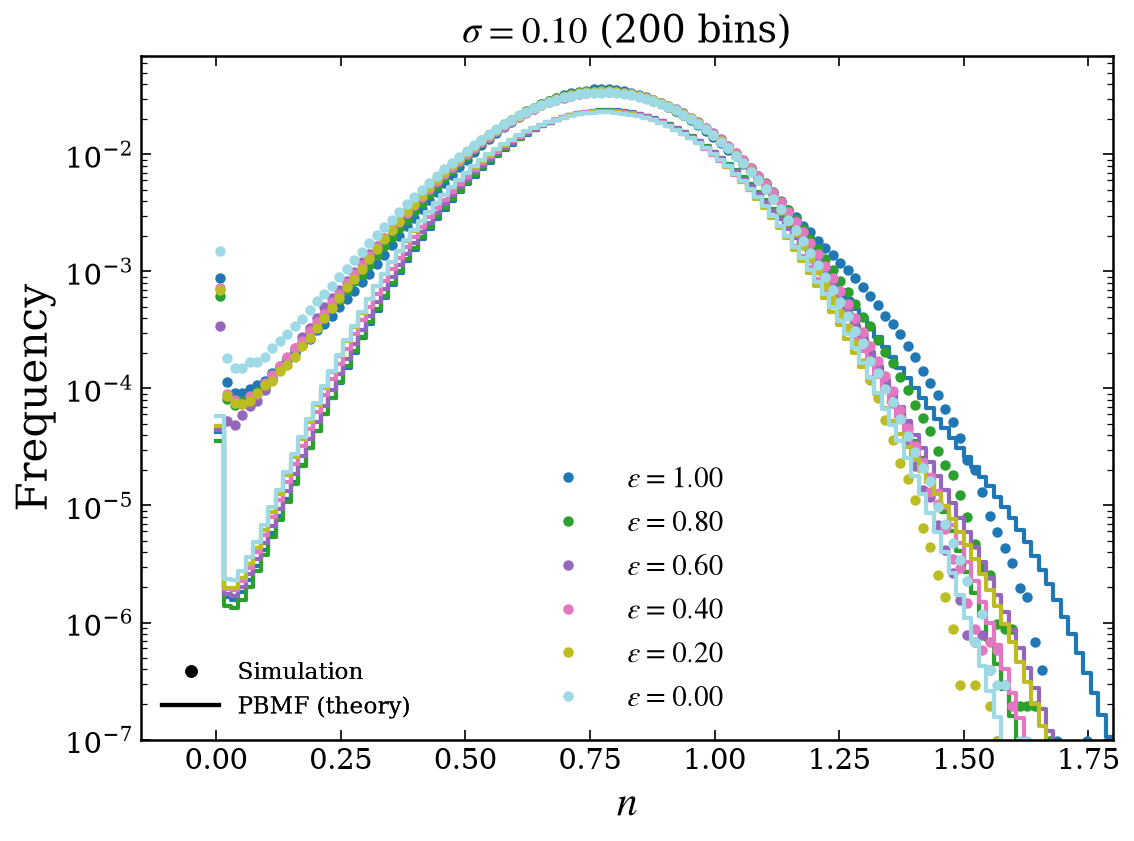

In [9]:
# Fixed sigma, one curve-pair per epsilon
plot_avg_frequency_histogram_vs_eps(sigma=0.10, n_bins=200, eps_values=eps_list, 
                                    ymin=1e-7, ymax=7e-2, xmax=1.8, logscaley=True)

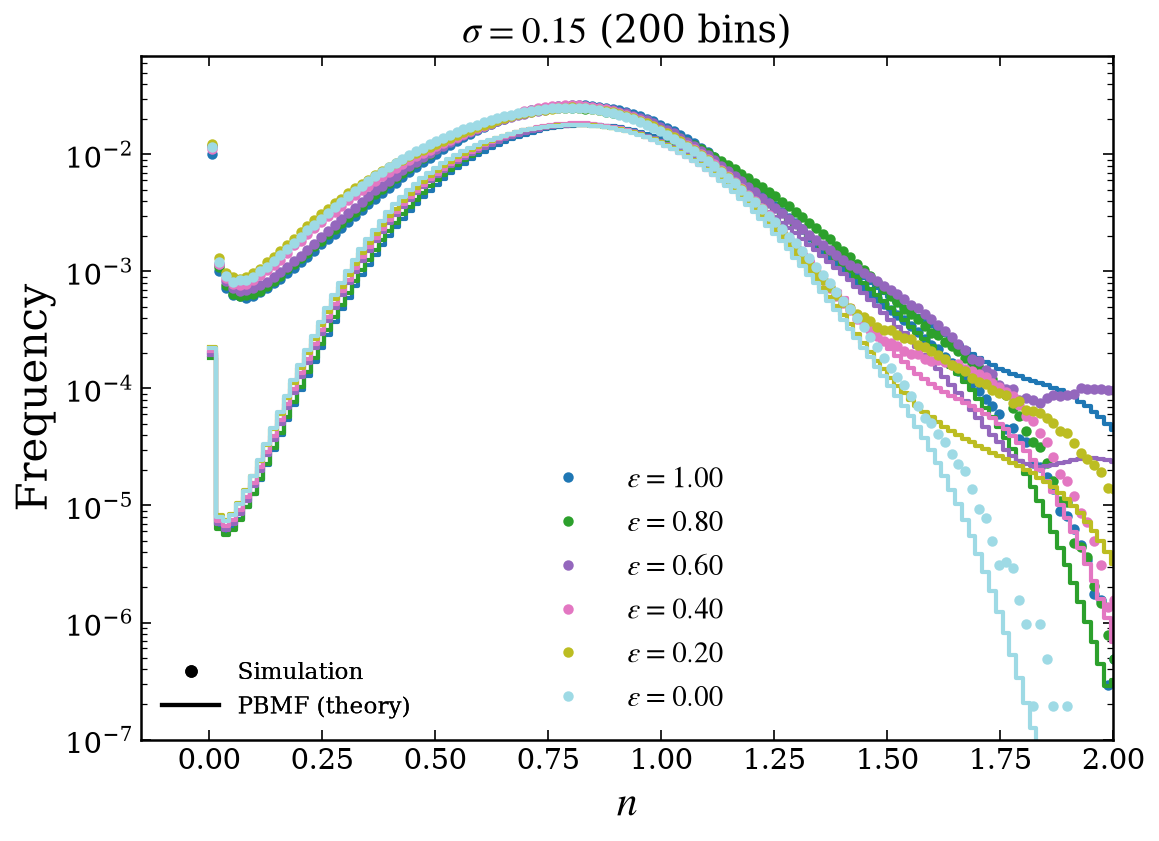

In [10]:
# Fixed sigma, one curve-pair per epsilon
plot_avg_frequency_histogram_vs_eps(sigma=0.15, n_bins=200, eps_values=eps_list, 
                                    ymin=1e-7, ymax=7e-2, xmax=2, logscaley=True)

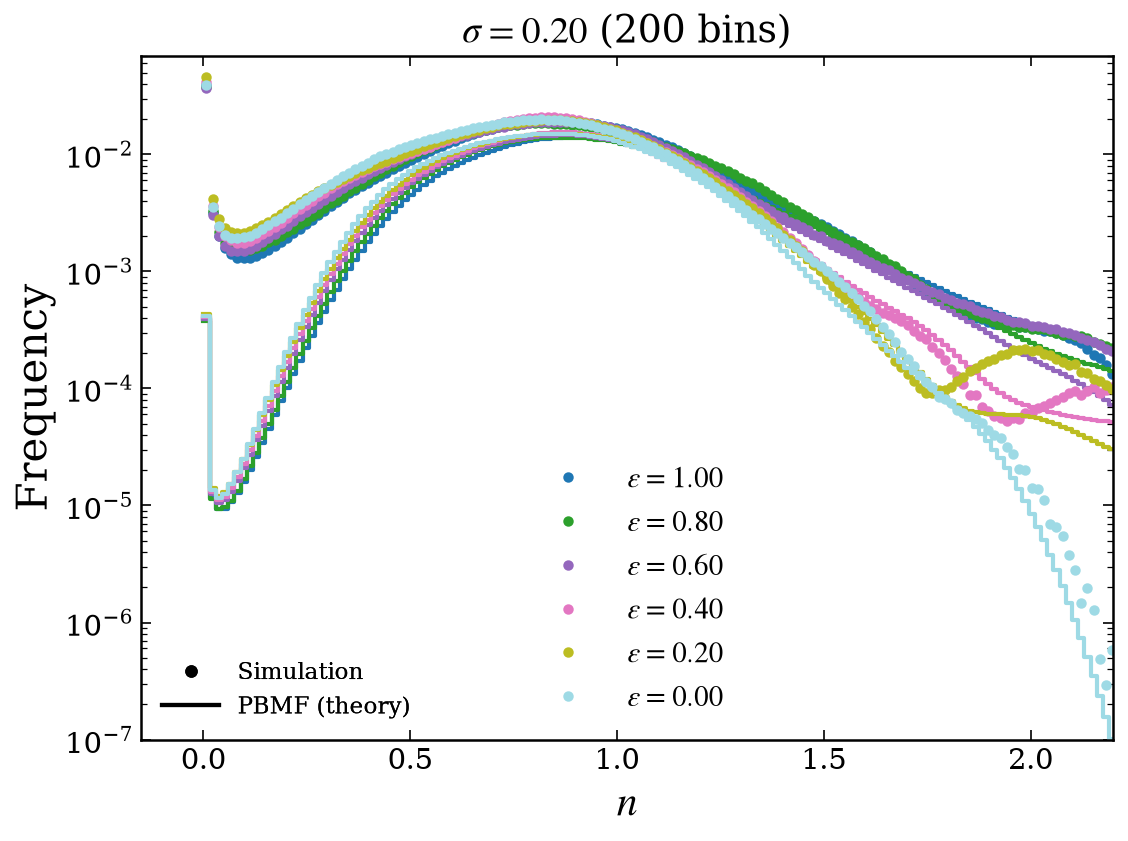

In [11]:
# Fixed sigma, one curve-pair per epsilon
plot_avg_frequency_histogram_vs_eps(sigma=0.20, n_bins=200, eps_values=eps_list, 
                                    ymin=1e-7, ymax=7e-2, xmax=2.2, logscaley=True)

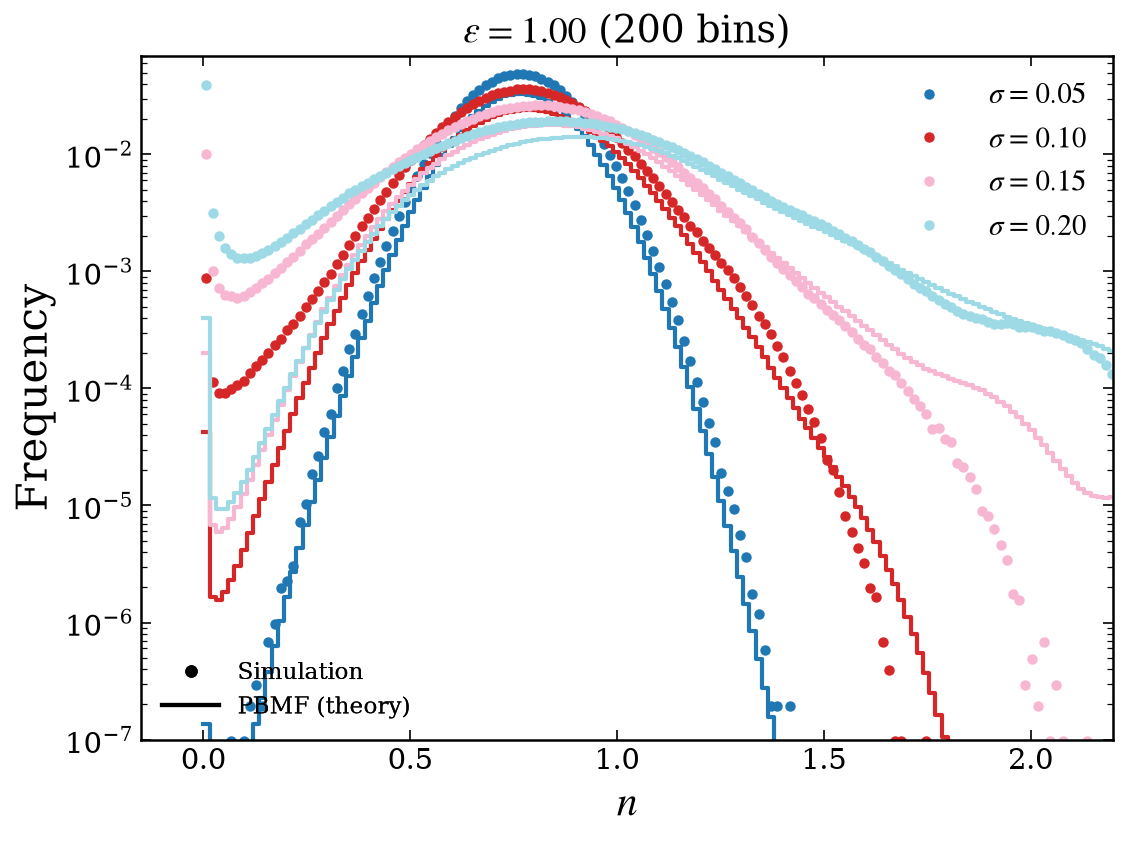

In [12]:
# Fixed epsilon, one curve-pair per sigma
plot_avg_frequency_histogram_vs_sigma(eps=1.0, n_bins=200, logscaley=True, 
                                      ymin=1e-7, ymax=7e-2, xmax=2.2)

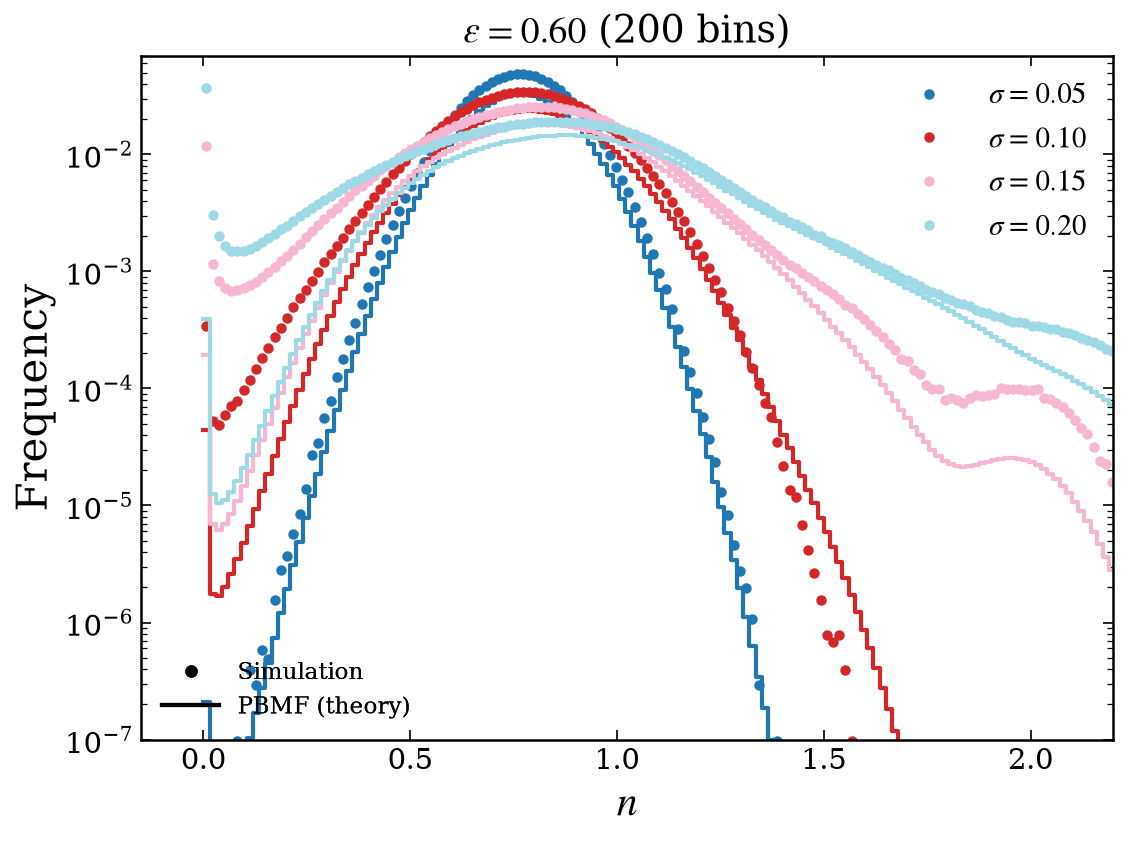

In [13]:
# Fixed epsilon, one curve-pair per sigma
plot_avg_frequency_histogram_vs_sigma(eps=0.6, n_bins=200, logscaley=True, 
                                      ymin=1e-7, ymax=7e-2, xmax=2.2)

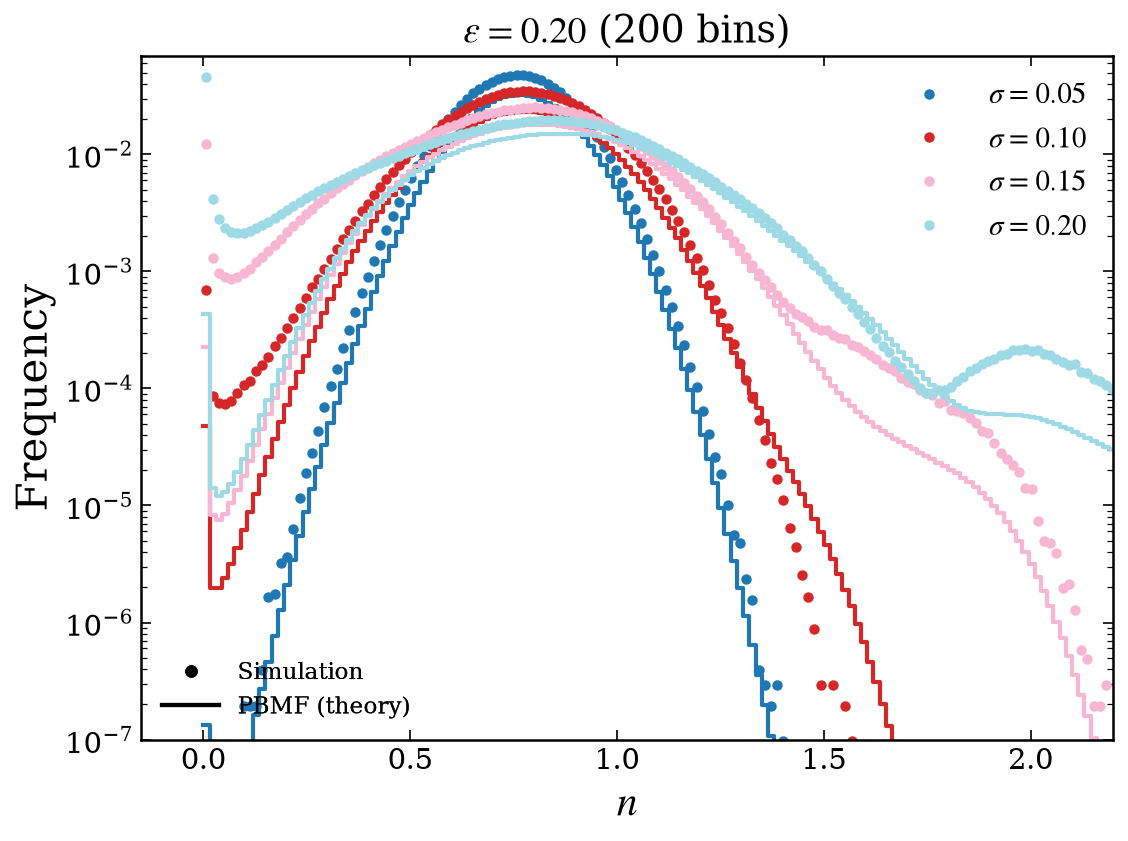

In [14]:
# Fixed epsilon, one curve-pair per sigma
plot_avg_frequency_histogram_vs_sigma(eps=0.2, n_bins=200, logscaley=True, 
                                      ymin=1e-7, ymax=7e-2, xmax=2.2)

## 2. Individual species distributions: the species PBMF flagged as top non-Gaussian

For a given (epsilon, sigma), `preprocess_Langevin_distributions.py --pbmf-dir` already pooled every PBMF `*_top_nongaussian_species.txt` replicate to find the species PBMF ever flagged as most non-Gaussian, and wrote each such species' own count/frequency/density (from the Langevin data) to one `*_PBMF_top_nongaussian_species.txt` file. This section re-pools the matching raw PBMF per-species curves (mean over whichever replicates happened to flag that particular species) and compares them the same way as section 1.

Only the raw $P(n)$ distribution is available here (not $\hat{P}(n)$): the companion files only carry count/frequency/density of $P$, since there is no natural "count" for the rescaled $\hat{P}$.

In [16]:
PBMF_SPECIES_HEADER_RE = re.compile(r"species=(\d+)")


def find_pbmf_top_nongaussian_files(pbmf_dist_dir, eps, sigma, tol=1e-6):
    pattern = os.path.join(pbmf_dist_dir, f"PBMF_gr_in_RRG_*{PBMF_TOP_NONGAUSSIAN_SUFFIX}")
    matches = []
    for path in sorted(glob.glob(pattern)):
        reconstructed = os.path.basename(path)[:-len(PBMF_TOP_NONGAUSSIAN_SUFFIX)] + ".txt"
        params = parse_pbmf_filename(reconstructed)
        if params is None:
            continue
        if np.isclose(params["eps"], eps, atol=tol) and np.isclose(params["sigma"], sigma, atol=tol):
            matches.append(path)
    return matches


def load_pbmf_top_nongaussian_curves(pbmf_dist_dir, eps, sigma, tol=1e-6):
    """Return dict: species_num (1-indexed, PBMF's own convention) -> list of (n, P, Phat)
    curves, one per PBMF replicate file whose own top-N list happened to include that species
    (not every replicate selects the same species)."""
    paths = find_pbmf_top_nongaussian_files(pbmf_dist_dir, eps, sigma, tol=tol)
    curves = {}
    for path in paths:
        header_species = []
        column_line = None
        with open(path) as f:
            for line in f:
                if not line.startswith("#"):
                    break
                column_line = line[1:].strip()
                m = PBMF_SPECIES_HEADER_RE.search(line)
                if m:
                    header_species.append(int(m.group(1)))
        if column_line is None or not header_species:
            continue
        columns = column_line.split("\t")
        data = np.loadtxt(path, comments="#")
        n = data[:, 0]
        for sp in header_species:
            try:
                p_idx = columns.index(f"P_species{sp}")
                phat_idx = columns.index(f"Phat_species{sp}")
            except ValueError:
                continue
            curves.setdefault(sp, []).append((n, data[:, p_idx], data[:, phat_idx]))
    return curves


def pooled_species_curve(curves_list, use_phat=False):
    """Average (over whichever PBMF replicates flagged this species) a species' P(n) or
    Phat(n) curve, zero-padding shorter (early-truncated) replicate grids up to the longest,
    same convention as load_pbmf_pooled_average."""
    col = 2 if use_phat else 1
    n_ref = max((c[0] for c in curves_list), key=len)
    stacked = np.zeros((len(curves_list), len(n_ref)))
    for i, c in enumerate(curves_list):
        vals = c[col]
        stacked[i, :len(vals)] = vals
    return n_ref, stacked.mean(axis=0), len(curves_list)


def find_langevin_pbmf_top_nongaussian_file(langevin_dist_dir, eps, sigma, tol=1e-6):
    pattern = os.path.join(langevin_dist_dir, f"Lotka-Volterra_*{LANGEVIN_PBMF_TOP_NONGAUSSIAN_SUFFIX}")
    for path in sorted(glob.glob(pattern)):
        reconstructed = os.path.basename(path)[:-len(LANGEVIN_PBMF_TOP_NONGAUSSIAN_SUFFIX)] + ".txt"
        params = parse_langevin_filename(reconstructed)
        if params is None:
            continue
        if np.isclose(params["epsilon"], eps, atol=tol) and np.isclose(params["sigma"], sigma, atol=tol):
            return path
    return None


def load_langevin_species_data(path):
    """Return (n, dict: species_idx (0-indexed, Langevin's own convention) -> (count, freq,
    density)) from a Langevin *_PBMF_top_nongaussian_species.txt file."""
    column_line = None
    with open(path) as f:
        for line in f:
            if not line.startswith("#"):
                break
            column_line = line[1:].strip()
    columns = column_line.split("\t")
    data = np.loadtxt(path, comments="#")
    n = data[:, 0]
    species_re = re.compile(r"count_species(\d+)")
    species_indices = sorted(int(m.group(1)) for c in columns for m in [species_re.match(c)] if m)
    per_species = {}
    for idx in species_indices:
        count = data[:, columns.index(f"count_species{idx}")]
        freq = data[:, columns.index(f"freq_species{idx}")]
        density = data[:, columns.index(f"density_species{idx}")]
        per_species[idx] = (count, freq, density)
    return n, per_species


def list_pbmf_selected_species(eps, sigma, langevin_dist_dir=LANGEVIN_DIST_DIR):
    """The (0-indexed) species PBMF flagged as top non-Gaussian for (eps, sigma), i.e. the
    species available to plot_species_*_histogram below."""
    path = find_langevin_pbmf_top_nongaussian_file(langevin_dist_dir, eps, sigma)
    if path is None:
        return []
    _, per_species = load_langevin_species_data(path)
    return sorted(per_species.keys())

In [17]:
def _plot_species_multi(eps, sigma, n_bins, kind, species_indices=None,
                         pbmf_dist_dir=PBMF_DIST_DIR, langevin_dist_dir=LANGEVIN_DIST_DIR,
                         n_samples=N_SAMPLES,
                         figsize=(8, 6), dpi=150, legend_loc='best', legend_fontsize=14,
                         title_fontsize=18, label_fontsize=20, tick_fontsize=14,
                         linewidth=2, markersize=4, logscalex=False, logscaley=False, ax=None, save_to=None,
                         xmin=None, xmax=None, ymin=None, ymax=None, title=None):
    """Overlay several species (simulation as small points at bin centers + PBMF theory as a
    solid line, one color per species) in one plot. species_indices are Langevin's 0-indexed
    species numbers (see list_pbmf_selected_species); every PBMF-flagged species for
    (eps, sigma) is used if not given.
    """
    if kind not in ("frequency", "count"):
        raise ValueError("kind must be 'frequency' or 'count'")

    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "axes.linewidth": 1.2,
    })

    langevin_path = find_langevin_pbmf_top_nongaussian_file(langevin_dist_dir, eps, sigma)
    if langevin_path is None:
        print(f"  [warn] no Langevin PBMF-top-nongaussian file for eps={eps}, sigma={sigma}")
        return
    native_centers, per_species = load_langevin_species_data(langevin_path)

    if species_indices is None:
        species_indices = sorted(per_species.keys())
    if not species_indices:
        print("  [warn] no species to plot")
        return

    pbmf_curves = load_pbmf_top_nongaussian_curves(pbmf_dist_dir, eps, sigma)
    dn_native = native_centers[1] - native_centers[0]

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        fig.subplots_adjust(left=0.17, bottom=0.14, right=0.98, top=0.90)
    else:
        fig = ax.figure
    color_cycle = plt.cm.tab20(np.linspace(0, 1, max(len(species_indices), 1)))

    for idx, species_idx in enumerate(species_indices):
        color = color_cycle[idx % len(color_cycle)]
        if species_idx not in per_species:
            print(f"  [warn] species {species_idx} not in {os.path.basename(langevin_path)}")
            continue
        native_count, native_freq, _native_density = per_species[species_idx]
        new_edges, new_centers, sim_count, sim_freq, _sim_density = rebin_columns(
            native_centers, native_count, native_freq, dn_native, n_bins
        )

        species_num = species_idx + 1  # PBMF's own (1-indexed) convention
        if species_num not in pbmf_curves:
            print(f"  [warn] species {species_idx} (PBMF species={species_num}) not flagged by "
                  f"any PBMF replicate for eps={eps}, sigma={sigma}")
            continue
        pbmf_n, pbmf_density, _n_replicates = pooled_species_curve(pbmf_curves[species_num])
        pbmf_freq = integrate_over_bins(pbmf_n, pbmf_density, new_edges)
        pbmf_count = pbmf_freq * n_samples

        sim_vals = sim_freq if kind == "frequency" else sim_count
        pbmf_vals = pbmf_freq if kind == "frequency" else pbmf_count

        ax.plot(new_centers, sim_vals, marker="o", linestyle="none", markersize=markersize,
                color=color, label=f"species {species_idx}")
        ax.step(new_edges, np.append(pbmf_vals, pbmf_vals[-1]), where="post",
                linewidth=linewidth, color=color)

    if logscalex:
        ax.set_xscale("log")
    if logscaley:
        ax.set_yscale("log")
    ax.set_xlabel(r"$n$", fontsize=label_fontsize)
    ax.set_ylabel("Frequency" if kind == "frequency" else "Count", fontsize=label_fontsize)
    ttl = title if title is not None else fr"$\epsilon={eps:.2f}$, $\sigma={sigma:.2f}$ ({n_bins} bins)"
    ax.set_title(ttl, fontsize=title_fontsize)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=3)
    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=5)
    if logscalex:
        ax.xaxis.set_major_formatter(LogFormatterMathtext())
    if logscaley:
        ax.yaxis.set_major_formatter(LogFormatterMathtext())

    main_legend = ax.legend(loc=legend_loc, fontsize=legend_fontsize, frameon=False, handlelength=2.5)
    ax.add_artist(main_legend)
    _add_style_legend(ax)

    if xmin is not None:
        ax.set_xlim(left=xmin)
    if xmax is not None:
        ax.set_xlim(right=xmax)
    if ymin is not None:
        ax.set_ylim(bottom=ymin)
    if ymax is not None:
        ax.set_ylim(top=ymax)

    if save_to is not None:
        fig.savefig(save_to)
    plt.show()


def plot_species_frequency_histogram(eps, sigma, n_bins, species_indices=None, **kwargs):
    """Frequency histogram, one curve-pair per species (see _plot_species_multi); every
    PBMF-flagged species for (eps, sigma) is shown if species_indices is not given."""
    _plot_species_multi(eps, sigma, n_bins, kind="frequency", species_indices=species_indices, **kwargs)


def plot_species_count_histogram(eps, sigma, n_bins, species_indices=None, **kwargs):
    """Like plot_species_frequency_histogram, but on a count scale (frequency * n_samples for
    both sides -- see the N_SAMPLES configuration cell)."""
    _plot_species_multi(eps, sigma, n_bins, kind="count", species_indices=species_indices, **kwargs)

### Examples

PBMF-flagged species for eps=1.0, sigma=0.05: [9, 25, 413, 448, 744, 828, 862, 980, 1016]


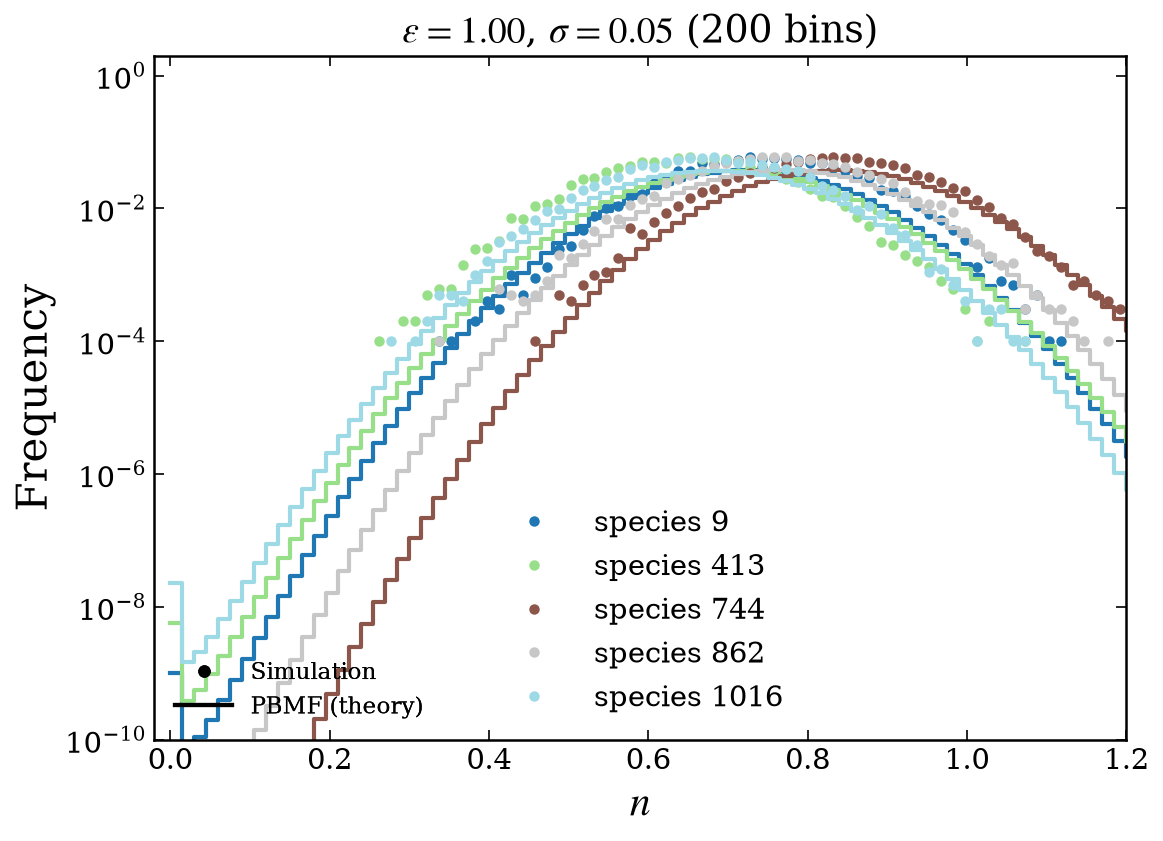

In [19]:
eps, sigma = 1.0, 0.05
species_list = list_pbmf_selected_species(eps, sigma)
print(f"PBMF-flagged species for eps={eps}, sigma={sigma}: {species_list}")
species_plot = [9, 413, 744, 862, 1016]
# All PBMF-flagged species together, in one plot
plot_species_frequency_histogram(eps, sigma, n_bins=200, logscaley=True, 
                                 ymin=1e-10, ymax=2, xmin=-0.02, xmax=1.2, 
                                 species_indices=species_plot)

PBMF-flagged species for eps=1.0, sigma=0.1: [145, 185, 216, 298, 540, 701, 739, 786, 967]


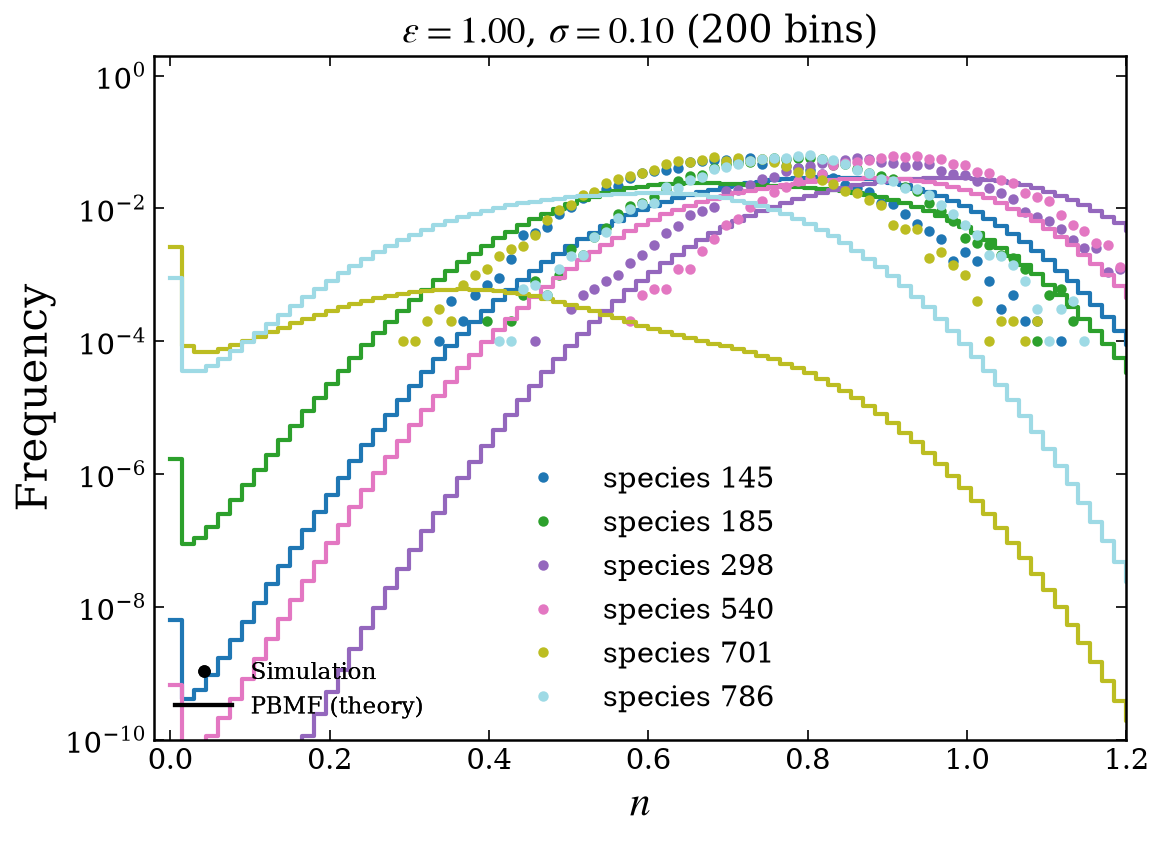

In [21]:
eps, sigma = 1.0, 0.10
species_list = list_pbmf_selected_species(eps, sigma)
print(f"PBMF-flagged species for eps={eps}, sigma={sigma}: {species_list}")
# All PBMF-flagged species together, in one plot
species_plot = [145, 185, 298, 540, 701, 786]
plot_species_frequency_histogram(eps, sigma, n_bins=200, logscaley=True, 
                                 ymin=1e-10, ymax=2, xmin=-0.02, xmax=1.2, 
                                 species_indices=species_plot)

PBMF-flagged species for eps=0.6, sigma=0.1: [208, 214, 366, 484, 525, 814, 859, 949, 1018]


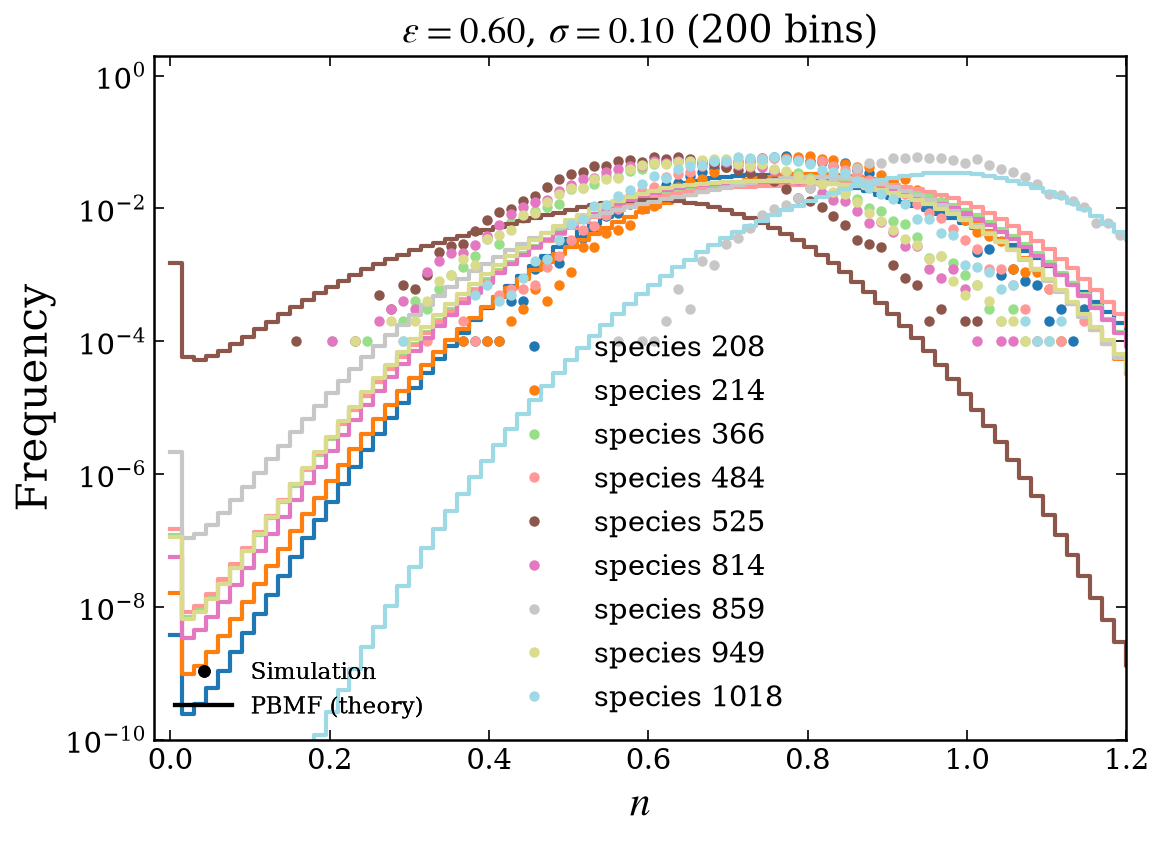

In [22]:
eps, sigma = 0.6, 0.10
species_list = list_pbmf_selected_species(eps, sigma)
print(f"PBMF-flagged species for eps={eps}, sigma={sigma}: {species_list}")
# All PBMF-flagged species together, in one plot
plot_species_frequency_histogram(eps, sigma, n_bins=200, logscaley=True, 
                                 ymin=1e-10, ymax=2, xmin=-0.02, xmax=1.2)

PBMF-flagged species for eps=0.2, sigma=0.1: [90, 185, 359, 450, 599, 730, 743, 807, 973]


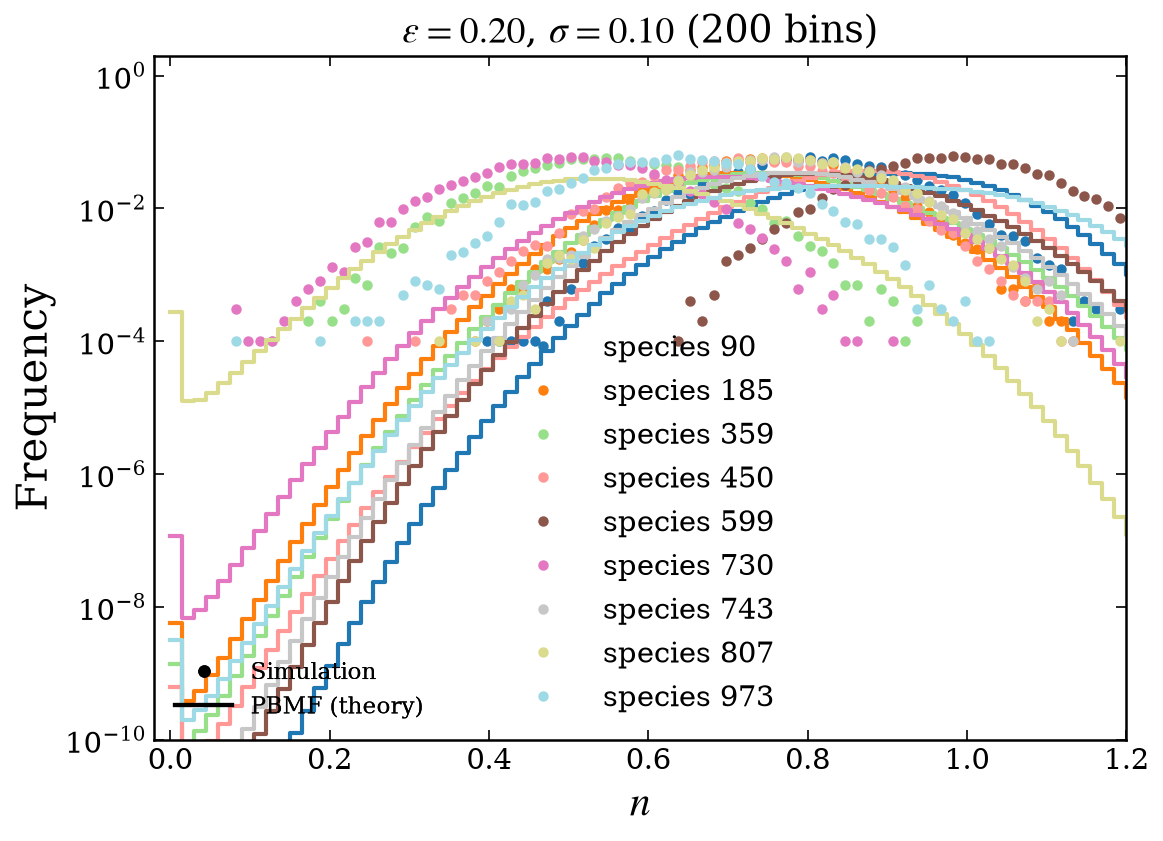

In [23]:
eps, sigma = 0.2, 0.10
species_list = list_pbmf_selected_species(eps, sigma)
print(f"PBMF-flagged species for eps={eps}, sigma={sigma}: {species_list}")
# All PBMF-flagged species together, in one plot
plot_species_frequency_histogram(eps, sigma, n_bins=200, logscaley=True, 
                                 ymin=1e-10, ymax=2, xmin=-0.02, xmax=1.2)

PBMF-flagged species for eps=1.0, sigma=0.2: [3, 66, 130, 280, 303, 559, 568, 701, 963]


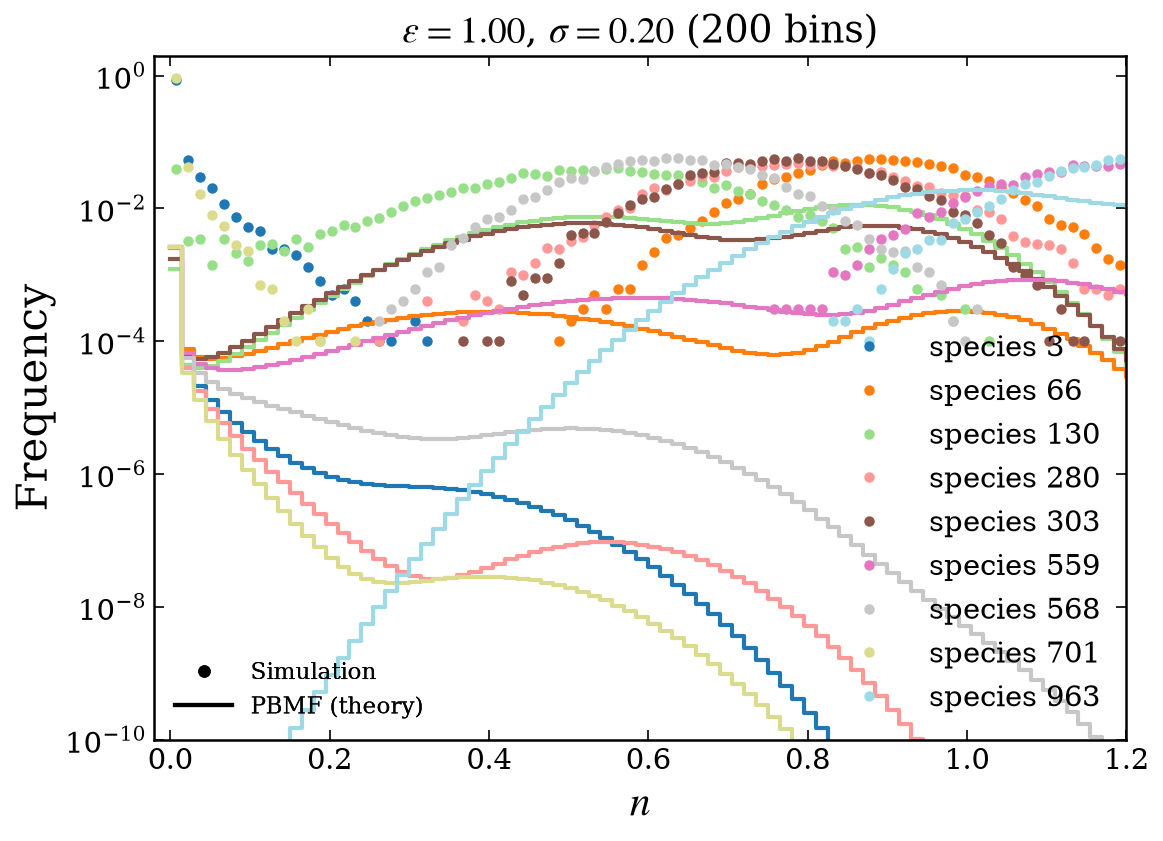

In [24]:
eps, sigma = 1.0, 0.20
species_list = list_pbmf_selected_species(eps, sigma)
print(f"PBMF-flagged species for eps={eps}, sigma={sigma}: {species_list}")
# All PBMF-flagged species together, in one plot
plot_species_frequency_histogram(eps, sigma, n_bins=200, logscaley=True, 
                                 ymin=1e-10, ymax=2, xmin=-0.02, xmax=1.2)

PBMF-flagged species for eps=0.6, sigma=0.2: [247, 362, 510, 701, 770, 819, 857, 999, 1016]


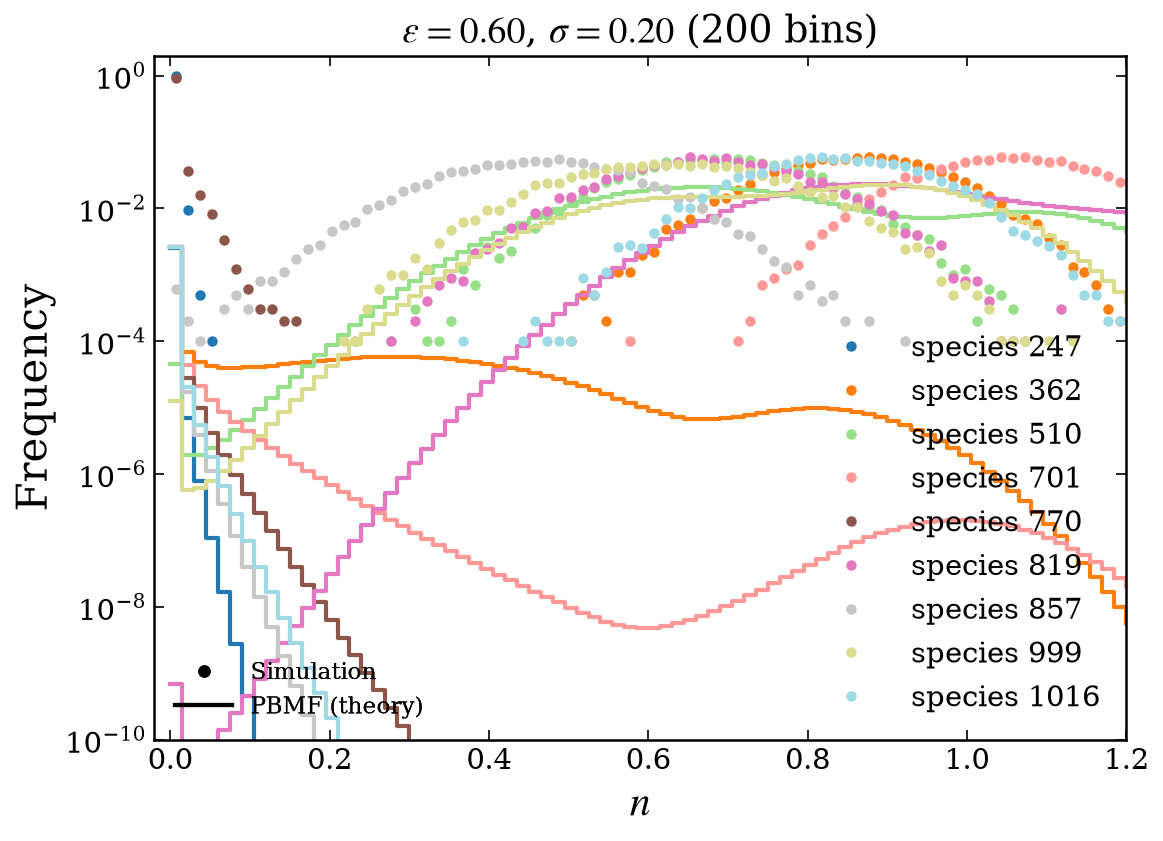

In [25]:
eps, sigma = 0.6, 0.20
species_list = list_pbmf_selected_species(eps, sigma)
print(f"PBMF-flagged species for eps={eps}, sigma={sigma}: {species_list}")
# All PBMF-flagged species together, in one plot
plot_species_frequency_histogram(eps, sigma, n_bins=200, logscaley=True, 
                                 ymin=1e-10, ymax=2, xmin=-0.02, xmax=1.2)

PBMF-flagged species for eps=0.2, sigma=0.2: [292, 313, 420, 479, 629, 791, 838, 880, 954]


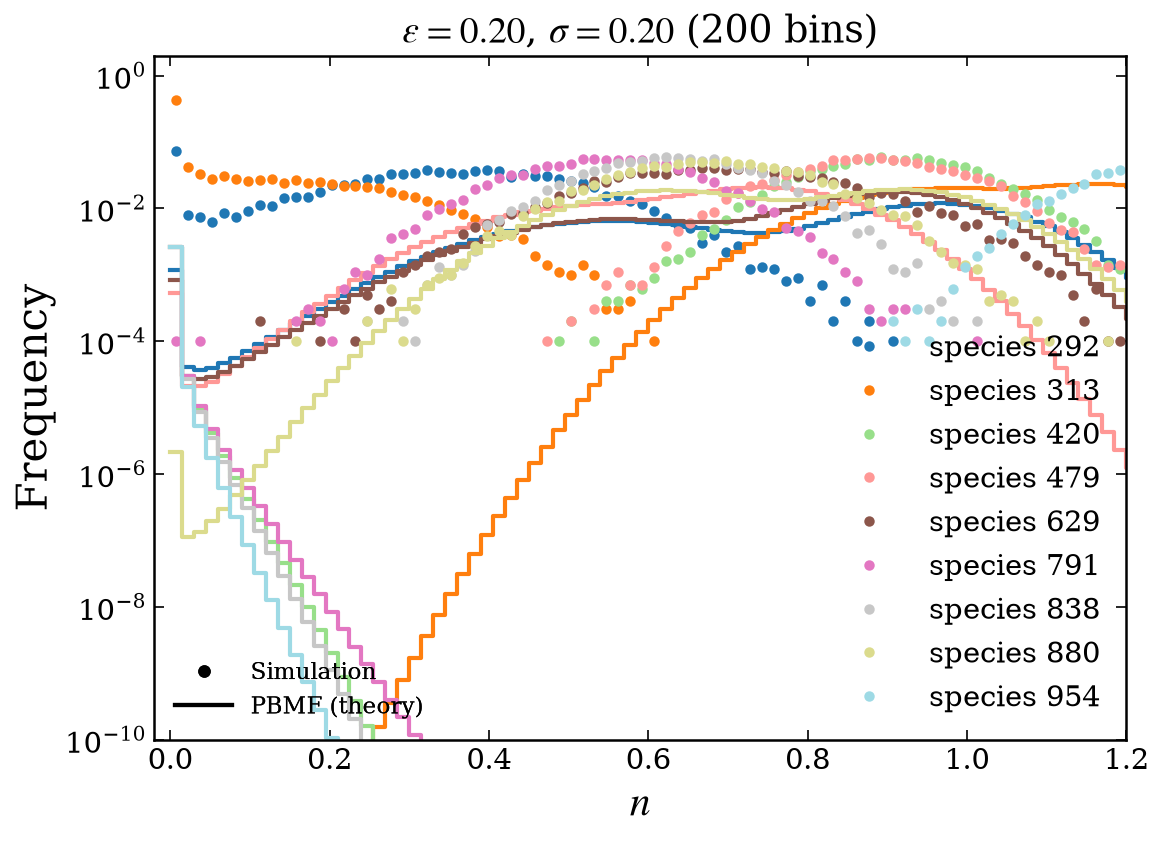

In [27]:
eps, sigma = 0.2, 0.20
species_list = list_pbmf_selected_species(eps, sigma)
print(f"PBMF-flagged species for eps={eps}, sigma={sigma}: {species_list}")
# All PBMF-flagged species together, in one plot
plot_species_frequency_histogram(eps, sigma, n_bins=200, logscaley=True, 
                                 ymin=1e-10, ymax=2, xmin=-0.02, xmax=1.2)